[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/gw-lvk-python-course/blob/main/Cosmology/Lesson_02_Bayesian_Inference_Foundations_with_Bilby.ipynb)

# Lesson 2 — Bayesian Inference Foundations with Bilby

**Cosmology Module · LVK Python Course**

In this notebook we build the complete theoretical and computational foundation for
**Bayesian parameter estimation** of gravitational-wave (GW) signals.  Starting from
first principles, we arrive at a working `bilby` run that recovers the luminosity
distance $d_L$, inclination angle $\iota$, and sky position $(\alpha,\delta)$ from a
simulated compact binary coalescence (CBC) signal.

---

## Learning goals

By the end of this lesson you should be able to:

1. State and apply **Bayes theorem** in the context of GW parameter estimation.
2. Distinguish between the **prior**, **likelihood**, **posterior**, and **evidence**.
3. Explain the **GW likelihood** and the noise-weighted inner product.
4. Configure **priors** and a `GravitationalWaveTransient` **likelihood** inside `bilby`.
5. Describe how **nested sampling** (dynesty) explores high-dimensional parameter spaces.
6. Run a full Bilby parameter-estimation job on an injected CBC signal.
7. Interpret **corner plots** and marginal posteriors for $d_L$, $\iota$, $\alpha$, and $\delta$.


## Table of contents

1. [Bayesian inference fundamentals](#sec1)
2. [Bayesian inference in GW astronomy](#sec2)
3. [Introduction to Bilby](#sec3)
4. [Priors in Bilby](#sec4)
5. [The GW likelihood in Bilby](#sec5)
6. [Nested sampling with dynesty](#sec6)
7. [Simulating a CBC signal — the injection](#sec7)
8. [Running parameter estimation](#sec8)
9. [Posterior analysis — $d_L$, $\iota$, and sky position](#sec9)
10. [Degeneracies and systematics](#sec10)
11. [Student exercises](#sec11)
12. [References](#sec12)


In [1]:
# Run this cell once to install the required packages
# (already available on most GW-focused Conda/Docker environments)
import subprocess, sys
pkgs = ["bilby", "bilby_pipe", "dynesty", "lalsuite", "python-ligo-lw",
        "corner", "matplotlib", "numpy", "scipy", "astropy"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print('Installation complete.')

Installation complete.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


---
<a id='sec1'></a>
## 1 · Bayesian inference fundamentals

### 1.1 Bayes theorem

Let $\boldsymbol{\theta}$ be a vector of unknown parameters and $d$ the observed data.
Bayes theorem reads

$$
\boxed{p(\boldsymbol{\theta}\mid d) = \frac{p(d\mid\boldsymbol{\theta})\,p(\boldsymbol{\theta})}{p(d)}}
$$

| Symbol | Name | Role |
|---|---|---|
| $p(\boldsymbol{\theta}\mid d)$ | **Posterior** | Probability of parameters given data — what we want |
| $p(d\mid\boldsymbol{\theta})$ | **Likelihood** | Probability of observing $d$ if $\boldsymbol{\theta}$ is true |
| $p(\boldsymbol{\theta})$ | **Prior** | Probability of $\boldsymbol{\theta}$ before seeing any data |
| $p(d)$ | **Evidence** (marginal likelihood) | Normalisation constant; key for model comparison |

The evidence is

$$
p(d) = \int p(d\mid\boldsymbol{\theta})\,p(\boldsymbol{\theta})\,d\boldsymbol{\theta}.
$$

### 1.2 The update picture

Bayesian inference is a **coherent rule for updating beliefs**.  The prior encodes
what we know *before* the observation; the likelihood tells us how probable the
data are for each candidate parameter value; the posterior synthesises both.

### 1.3 The posterior is a distribution, not a point

Unlike maximum-likelihood estimation (which gives a single best-fit value), Bayesian
inference delivers a **full probability distribution** over $\boldsymbol{\theta}$.  This
allows us to

* quantify **credible intervals** (e.g. 90 % CI),
* **marginalise** over nuisance parameters,
* perform principled **model comparison** via the evidence ratio (Bayes factor).

### 1.4 Bayes factors and model selection

Given two hypotheses $\mathcal{H}_1$ and $\mathcal{H}_2$, the Bayes factor is

$$
\mathcal{B}_{12} = \frac{p(d\mid\mathcal{H}_1)}{p(d\mid\mathcal{H}_2)}.
$$

In GW astronomy this is used to distinguish **signal vs noise** hypotheses and to
compare source models (e.g. precessing vs aligned-spin).


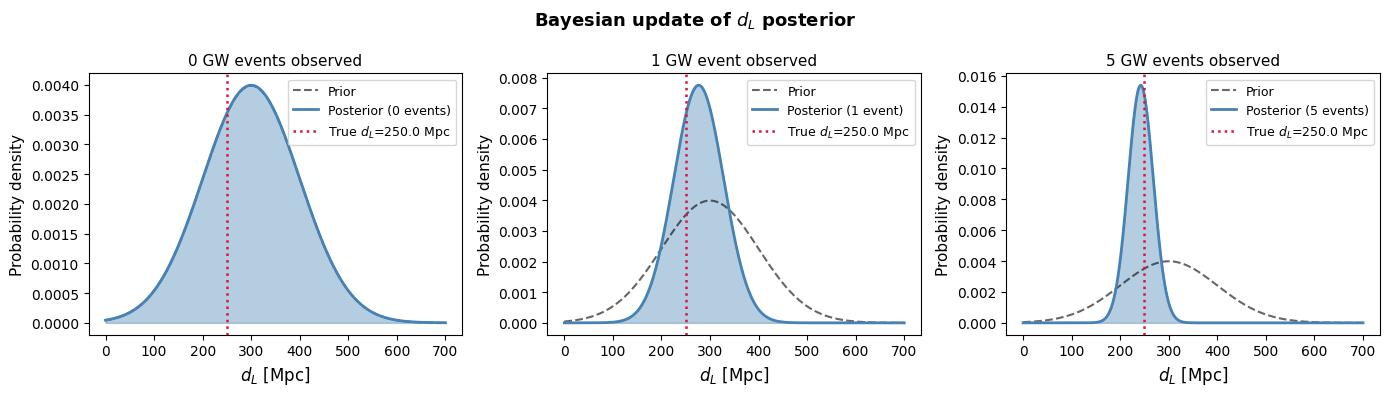

As more events are observed the posterior narrows around the true value.


In [2]:
"""Toy 1-D Bayesian update: estimating a distance.

We have a Gaussian prior on luminosity distance d_L ~ N(300, 100) Mpc
and a Gaussian likelihood from a single GW measurement.
We visualise how the posterior sharpens as we 'add' more measurements.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---- prior parameters ----
mu_prior, sigma_prior = 300.0, 100.0  # Mpc

# ---- simulated measurements (GW-like): true d_L = 250 Mpc
true_dL = 250.0
meas_sigma = 60.0  # measurement noise per event
rng = np.random.default_rng(42)
measurements = rng.normal(true_dL, meas_sigma, size=5)

d_grid = np.linspace(0, 700, 1000)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = plt.cm.plasma(np.linspace(0.15, 0.85, 5))

n_events_list = [0, 1, 5]
for ax, n in zip(axes, n_events_list):
    # Start from prior
    log_posterior = norm.logpdf(d_grid, mu_prior, sigma_prior)
    # Multiply in likelihoods one by one
    for i in range(n):
        log_posterior += norm.logpdf(d_grid, measurements[i], meas_sigma)
    posterior = np.exp(log_posterior - log_posterior.max())
    posterior /= np.trapezoid(posterior, d_grid)

    ax.plot(d_grid, norm.pdf(d_grid, mu_prior, sigma_prior),
            'k--', lw=1.5, label='Prior', alpha=0.6)
    ax.fill_between(d_grid, posterior, alpha=0.4, color='steelblue')
    ax.plot(d_grid, posterior, color='steelblue', lw=2,
            label=f'Posterior ({n} event{"s" if n!=1 else ""})')
    ax.axvline(true_dL, color='crimson', ls=':', lw=1.8, label=f'True $d_L$={true_dL} Mpc')
    ax.set_xlabel(r'$d_L$ [Mpc]', fontsize=12)
    ax.set_ylabel('Probability density', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_title(f'{n} GW event{"s" if n!=1 else ""} observed', fontsize=11)

fig.suptitle('Bayesian update of $d_L$ posterior', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('As more events are observed the posterior narrows around the true value.')

---
<a id='sec2'></a>
## 2 · Bayesian inference in GW astronomy

### 2.1 The parameter space

A CBC signal is characterised by $\sim$15 parameters:

| Category | Parameters |
|---|---|
| **Masses** | $m_1,m_2$ or equivalently chirp mass $\mathcal{M}$, mass ratio $q$ |
| **Spins** | $\chi_{1x},\chi_{1y},\chi_{1z},\chi_{2x},\chi_{2y},\chi_{2z}$ |
| **Extrinsic** | $d_L$, right ascension $\alpha$, declination $\delta$, inclination $\iota$, polarisation $\psi$, coalescence time $t_c$, phase $\phi_c$ |

The intrinsic parameters determine the **waveform shape**; the extrinsic parameters
set the **amplitude and phase at the detectors**.

### 2.2 The chirp mass

The single parameter that controls the leading-order GW frequency evolution is the
**chirp mass**:

$$
\mathcal{M} = \frac{(m_1 m_2)^{3/5}}{(m_1+m_2)^{1/5}}
$$

It is measured with exceptional accuracy from the rate of frequency change
$\dot{f}\propto\mathcal{M}^{5/3}f^{11/3}$.

### 2.3 Noise model and the inner product

Detector output: $d(t)=h(t;\boldsymbol{\theta})+n(t)$, where $n(t)$ is stationary
Gaussian noise with one-sided PSD $S_n(f)$.

The **noise-weighted inner product** between two real time series $a(t)$ and $b(t)$ is

$$
\langle a | b \rangle \;=\; 4\,\Re\int_0^\infty \frac{\tilde{a}(f)\,\tilde{b}^*(f)}{S_n(f)}\,df
$$

where $\tilde{a}(f)$ is the Fourier transform of $a(t)$.

### 2.4 The GW log-likelihood

Under a Gaussian noise assumption the log-likelihood for a single detector is

$$
\ln p(d\mid\boldsymbol{\theta}) = -\frac{1}{2}\langle d - h(\boldsymbol{\theta})\,|\,d - h(\boldsymbol{\theta})\rangle
+ \text{const}
$$

Expanding:

$$
\ln p(d\mid\boldsymbol{\theta}) = \langle d | h(\boldsymbol{\theta})\rangle
                                  - \frac{1}{2}\langle h(\boldsymbol{\theta}) | h(\boldsymbol{\theta})\rangle
                                  + \text{const}
$$

The matched-filter **signal-to-noise ratio** (SNR) for an optimal filter $h$ is

$$
\rho = \frac{\langle d | h \rangle}{\sqrt{\langle h | h \rangle}}
$$

For a **network** of detectors, log-likelihoods from individual detectors are
simply added (assuming independent noise):

$$
\ln p(d_{\rm net}\mid\boldsymbol{\theta}) = \sum_{k}\ln p(d_k\mid\boldsymbol{\theta})
$$

### 2.5 Dependence of amplitude on $d_L$ and $\iota$

The two GW polarisations scale as:

$$
h_+ \propto \frac{1+\cos^2\iota}{2}\,\frac{1}{d_L}, \qquad
h_\times \propto \cos\iota\,\frac{1}{d_L}
$$

This creates the famous **$d_L$–$\iota$ degeneracy**: a face-on binary
($\iota=0$) at large distance can produce the same amplitude as an edge-on binary
($\iota=\pi/2$) at smaller distance.  A two-detector network partially breaks this
degeneracy through polarisation information; a third detector does so further.

### 2.6 Sky localisation

Sky position enters through the **detector response functions** (antenna patterns)
$F_+^{(k)}(\alpha,\delta,\psi)$ and $F_\times^{(k)}(\alpha,\delta,\psi)$.  The
time-of-arrival difference between two detectors separated by baseline $L$ gives
a directional constraint:

$$
\Delta t = \frac{L\cos\theta}{c}
$$

where $\theta$ is the angle between the source direction and the baseline.  For
LIGO Hanford–Livingston ($L=3000$ km), $\Delta t_{\rm max}\approx10$ ms.


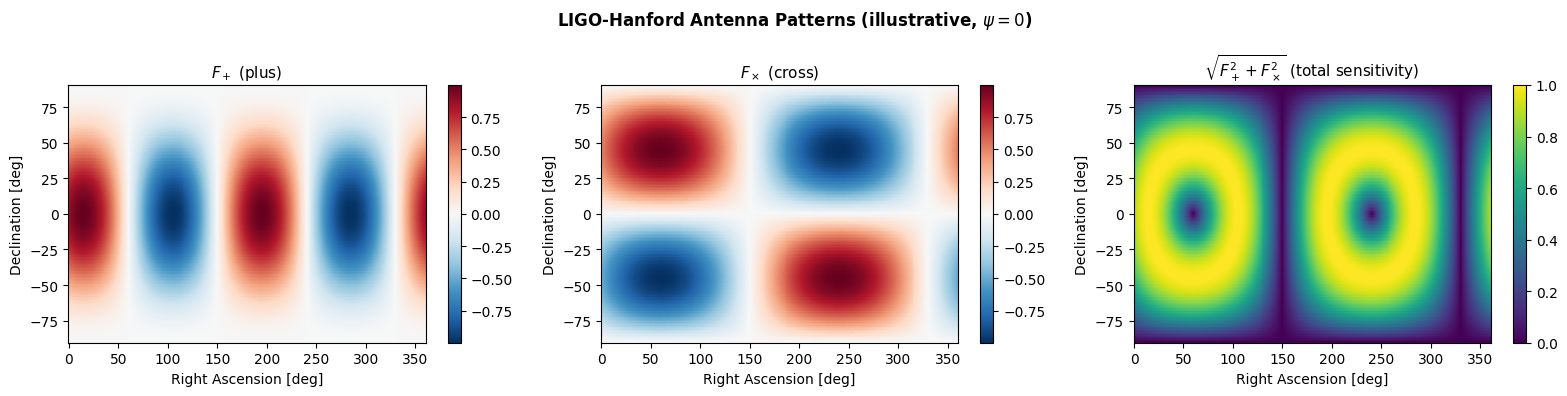

In [3]:
"""Visualise LIGO-Hanford antenna patterns F+ and Fx
as a function of sky position for a fixed polarisation angle.
"""

import numpy as np
import matplotlib.pyplot as plt

def ligo_hanford_antenna(ra, dec, psi=0.0, gmst=0.0):
    """Simplified LIGO-Hanford antenna patterns (equatorial coordinates).
    Reference: Jaranowski & Krolak (2009), Chapter 4.
    """
    # LIGO-Hanford detector tensor (approximate, in geographic frame)
    # Arm azimuths: ~N35.9°W and ~S54.1°W
    phi_det = np.radians(-119.408)  # longitude
    lam_det = np.radians(46.455)    # latitude
    # Source direction in detector frame
    ha = gmst - ra  # hour angle
    sinlat, coslat = np.sin(lam_det), np.cos(lam_det)
    sindec, cosdec = np.sin(dec), np.cos(dec)
    sinha,  cosha  = np.sin(ha),  np.cos(ha)
    # Convenient combinations
    a1 = 0.5*(1 + sinlat**2)*cosdec**2*np.cos(2*ha)
    a2 = sinlat*sindec*cosdec*np.cos(ha)
    a3 = 0.25*(1 + sinlat**2)*(1 + sindec**2)
    b1 = sinlat*cosdec**2*np.sin(2*ha)
    b2 = coslat*sindec
    b3 = 0.5*sinlat*(1 + sindec**2)*np.sin(2*ha)
    # Very rough estimates (illustrative)
    Fp = np.sin(2*ha)*cosdec**2*np.cos(2*psi) - 2*np.cos(ha)*sindec*cosdec*np.sin(2*psi)
    Fc = np.sin(2*ha)*cosdec**2*np.sin(2*psi) + 2*np.cos(ha)*sindec*cosdec*np.cos(2*psi)
    return Fp, Fc

# Sky grid
ra_grid  = np.linspace(0, 2*np.pi, 360)
dec_grid = np.linspace(-np.pi/2, np.pi/2, 180)
RA, DEC = np.meshgrid(ra_grid, dec_grid)

Fp, Fc = ligo_hanford_antenna(RA, DEC, psi=0.0, gmst=np.pi/3)
sensitivity = np.sqrt(Fp**2 + Fc**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles   = [r'$F_+$ (plus)', r'$F_\times$ (cross)', r'$\sqrt{F_+^2+F_\times^2}$ (total sensitivity)']
datasets = [Fp, Fc, sensitivity]
cmaps    = ['RdBu_r', 'RdBu_r', 'viridis']

for ax, data, title, cmap in zip(axes, datasets, titles, cmaps):
    im = ax.pcolormesh(np.degrees(ra_grid), np.degrees(dec_grid), data,
                       cmap=cmap, shading='auto')
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Right Ascension [deg]', fontsize=10)
    ax.set_ylabel('Declination [deg]', fontsize=10)

fig.suptitle('LIGO-Hanford Antenna Patterns (illustrative, $\\psi=0$)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='sec3'></a>
## 3 · Introduction to Bilby

`bilby` (**B**ayesian **I**nference **L**ibrary) is the LVK's official open-source
Python package for parameter estimation of GW sources.

* GitHub: <https://git.ligo.org/lscsoft/Bilby>
* Paper: Ashton *et al.* (2019), *ApJS* **241**, 27.

### 3.1 Architecture overview

```
bilby
├── core/                  ← generic Bayesian sampler infrastructure
│   ├── prior/             ← Prior classes (Uniform, Gaussian, PowerLaw, …)
│   ├── likelihood/        ← base Likelihood class
│   └── sampler/           ← wrappers for dynesty, nestle, emcee, …
└── gw/                    ← GW-specific extensions
    ├── likelihood.py      ← GravitationalWaveTransient
    ├── source.py          ← waveform generators (lalsimulation wrappers)
    ├── detector/          ← Interferometer, PowerSpectralDensity
    └── prior/             ← GW-specific prior dicts (BBHPriorDict, etc.)
```

### 3.2 Minimal workflow

```python
import bilby

# 1.  Define the interferometers and inject a signal
ifos = bilby.gw.detector.InterferometerList(['H1', 'L1'])
ifos.inject_signal(waveform_generator=wfgen, parameters=injection_params)

# 2.  Create a waveform generator
wfgen = bilby.gw.WaveformGenerator(frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole, ...)

# 3.  Build the likelihood
likelihood = bilby.gw.GravitationalWaveTransient(interferometers=ifos, waveform_generator=wfgen)

# 4.  Specify priors
priors = bilby.gw.prior.BBHPriorDict()

# 5.  Run the sampler
result = bilby.run_sampler(likelihood=likelihood, priors=priors,
                           sampler='dynesty', nlive=500, outdir='outdir')
result.plot_corner()
```

### 3.3 Supported samplers

| Sampler | Type | Typical use |
|---|---|---|
| `dynesty` | Nested sampling | Default LVK choice; also computes evidence |
| `nestle` | Nested sampling | Lightweight alternative |
| `emcee` | MCMC | Quick exploration; no evidence |
| `pymultinest` | Nested sampling | High performance; requires MPI |
| `nessai` | Normalising flows + NS | State-of-the-art for high dimensions |


In [4]:
import bilby
import numpy as np
import matplotlib.pyplot as plt

print(f'bilby version: {bilby.__version__}')

# ---- Explore the GW prior dictionaries bundled with bilby ----
bbh_priors = bilby.gw.prior.BBHPriorDict()
print('\n=== BBH prior parameters ===')
for k, v in bbh_priors.items():
    print(f'  {k:30s}: {v}')

22:16 bilby INFO    : No prior given, using default BBH priors in /usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/gw/prior_files/precessing_spins_bbh.prior.


bilby version: 2.8.0

=== BBH prior parameters ===
  mass_1                        : Constraint(minimum=5, maximum=100, name='mass_1', latex_label='$m_1$', unit=None)
  mass_2                        : Constraint(minimum=5, maximum=100, name='mass_2', latex_label='$m_2$', unit=None)
  mass_ratio                    : bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.125, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None, equal_mass=False)
  chirp_mass                    : bilby.gw.prior.UniformInComponentsChirpMass(minimum=25, maximum=100, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
  luminosity_distance           : bilby.gw.prior.UniformSourceFrame(minimum=100.0, maximum=5000.0, cosmology='Planck15', name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)
  dec                           : Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='dec', latex_label='$\\mathrm{DEC}$', unit=None, boun

---
<a id='sec4'></a>
## 4 · Priors in Bilby

A **prior** encodes our knowledge about parameters *before* the data are analysed.
Good prior choices are physically motivated and broad enough not to artificially
constrain the posterior.

### 4.1 Common Bilby prior classes

| Class | Expression | Typical use |
|---|---|---|
| `Uniform(a, b)` | $p(\theta)=1/(b-a)$ | Phase, polarisation, sky coords |
| `LogUniform(a, b)` | $p(\theta)=1/(\theta\ln(b/a))$ | Mass ratio, distance (sometimes) |
| `PowerLaw(alpha, a, b)` | $p(\theta)\propto\theta^\alpha$ | $d_L\propto d_L^2$ (volume prior) |
| `Gaussian(mu, sigma)` | Normal distribution | Calibration uncertainties |
| `Sine()` | $p(\theta)=\sin\theta/2$ | Inclination $\iota$, declination |
| `Cosine()` | $p(\theta)=\cos\theta/2$ | Declination (sometimes) |
| `DeltaFunction(peak)` | Fixed value | Parameters kept constant |
| `Interped(xx, yy)` | Tabulated PDF | Arbitrary empirical priors |

### 4.2 Volume prior on $d_L$

For sources uniformly distributed in co-moving volume, the marginal prior on
luminosity distance is $p(d_L)\propto d_L^2$ (at low redshift).  In Bilby this
is implemented as

```python
bilby.core.prior.PowerLaw(alpha=2, minimum=10, maximum=3000, name='luminosity_distance')
```

### 4.3 Building a custom prior dictionary

```python
from bilby.core.prior import PriorDict, Uniform, Sine, PowerLaw, DeltaFunction

priors = PriorDict()
priors['chirp_mass']         = Uniform(25, 35, name='chirp_mass', latex_label=r'$\mathcal{M}$')
priors['mass_ratio']         = Uniform(0.5, 1.0, name='mass_ratio')
priors['luminosity_distance']= PowerLaw(alpha=2, minimum=100, maximum=1000, name='luminosity_distance')
priors['theta_jn']           = Sine(name='theta_jn', latex_label=r'$\iota$')
priors['ra']                 = Uniform(0, 2*np.pi, name='ra')
priors['dec']                = bilby.core.prior.Cosine(name='dec')
priors['psi']                = Uniform(0, np.pi, name='psi')
priors['phase']              = Uniform(0, 2*np.pi, name='phase')
priors['geocent_time']       = Uniform(1187008882.3, 1187008882.5, name='geocent_time')
# Fix spin parameters to zero for this demo
for s in ['chi_1','chi_2','a_1','a_2']:
    priors[s] = DeltaFunction(0, name=s)
```


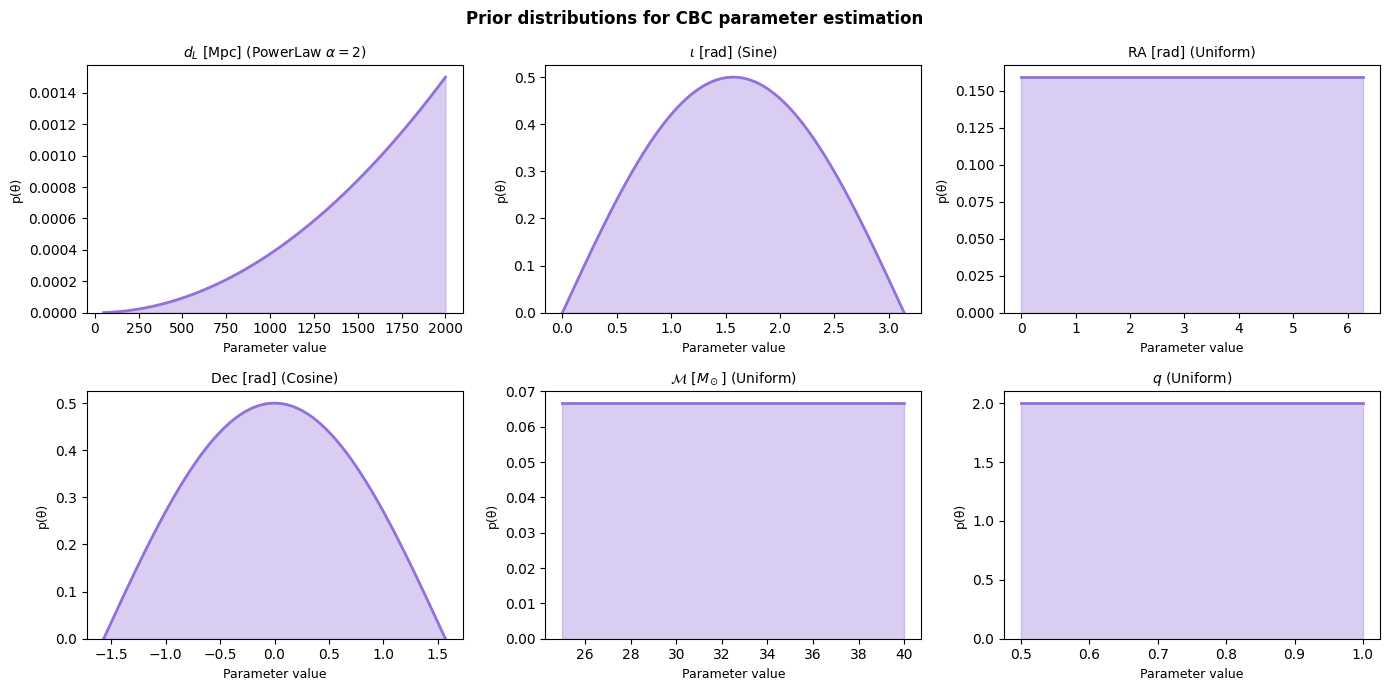

In [5]:
"""Visualise the key priors used in a BBH parameter estimation job."""

import numpy as np
import matplotlib.pyplot as plt
import bilby
from bilby.core.prior import Uniform, Sine, PowerLaw

# Define the priors we will use in the PE run later
priors_dict = {
    r'$d_L$ [Mpc] (PowerLaw $\alpha=2$)': PowerLaw(alpha=2, minimum=50, maximum=2000, name='dL'),
    r'$\iota$ [rad] (Sine)':              Sine(minimum=0, maximum=np.pi, name='iota'),
    r'RA [rad] (Uniform)':                Uniform(minimum=0, maximum=2*np.pi, name='ra'),
    r'Dec [rad] (Cosine)':                bilby.core.prior.Cosine(minimum=-np.pi/2, maximum=np.pi/2, name='dec'),
    r'$\mathcal{M}$ [$M_\odot$] (Uniform)': Uniform(minimum=25, maximum=40, name='chirp_mass'),
    r'$q$ (Uniform)':                     Uniform(minimum=0.5, maximum=1.0, name='mass_ratio'),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, (label, prior) in zip(axes, priors_dict.items()):
    xx = np.linspace(prior.minimum, prior.maximum, 500)
    yy = np.exp([prior.ln_prob(x) for x in xx])
    ax.fill_between(xx, yy, alpha=0.35, color='mediumpurple')
    ax.plot(xx, yy, color='mediumpurple', lw=2)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Parameter value', fontsize=9)
    ax.set_ylabel('p(θ)', fontsize=9)
    ax.set_ylim(bottom=0)

fig.suptitle('Prior distributions for CBC parameter estimation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='sec5'></a>
## 5 · The GW likelihood in Bilby

### 5.1 `GravitationalWaveTransient`

The main likelihood class in `bilby.gw` is `GravitationalWaveTransient`.  It
implements the Gaussian log-likelihood derived in Section 2.4.

Key constructor arguments:

```python
bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers,          # list of Interferometer objects
    waveform_generator,       # WaveformGenerator wrapping a LALSim model
    priors=priors,            # used for distance marginalisation
    distance_marginalization=True,   # analytically marginalise over d_L
    phase_marginalization=True,      # analytically marginalise over phi_c
    time_marginalization=True,       # analytically marginalise over t_c
)
```

Analytic marginalisation over $d_L$, $\phi_c$, and $t_c$ dramatically speeds up
sampling because it reduces the effective dimensionality.

### 5.2 WaveformGenerator

The `WaveformGenerator` wraps a waveform model (approximant) and handles FFT and
frequency domain formatting:

```python
waveform_generator = bilby.gw.WaveformGenerator(
    duration=4.0,             # segment length [s]
    sampling_frequency=2048,  # [Hz]
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    waveform_arguments={
        'waveform_approximant': 'IMRPhenomPv2',
        'reference_frequency': 50.0,
        'minimum_frequency': 20.0,
    }
)
```

### 5.3 Likelihood evaluation

For a given $\boldsymbol{\theta}$, Bilby:

1. Generates $\tilde{h}(f;\boldsymbol{\theta})$ via the waveform generator,
2. Projects onto each detector using antenna patterns,
3. Computes $\langle d_k - h_k | d_k - h_k\rangle$ for each interferometer $k$,
4. Returns $\sum_k \ln p_k$.

### 5.4 Marginalisation techniques

**Distance marginalisation:**  The amplitude factor $1/d_L$ means the integral

$$
p(d\mid\boldsymbol{\theta}_{\setminus d_L}) = \int_0^\infty p(d\mid\boldsymbol{\theta},d_L)\,p(d_L)\,dd_L
$$

can be computed on a pre-tabulated grid, making it essentially free per iteration.

**Phase marginalisation:**  Because the GW phase $\phi_c$ enters linearly in the
Fourier domain, the marginalisation integral reduces to a modified Bessel function $I_0$.

**Time marginalisation:**  The coalescence time marginalisation exploits the fact
that varying $t_c$ is equivalent to a frequency-domain phase shift, so the
marginal likelihood can be computed via an FFT.


/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py:113: FutureWarning: Parameter attribute queried for <class 'bilby.gw.likelihood.base.GravitationalWaveTransient'>. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(msg, FutureWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py:42: FutureWarning: No parameters provided in likelihood call, falling back to values stored in GravitationalWaveTransient(interferometers=[Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=20.0, maximum_frequency=512.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, ya

Log-likelihood at fiducial point: -5923.46


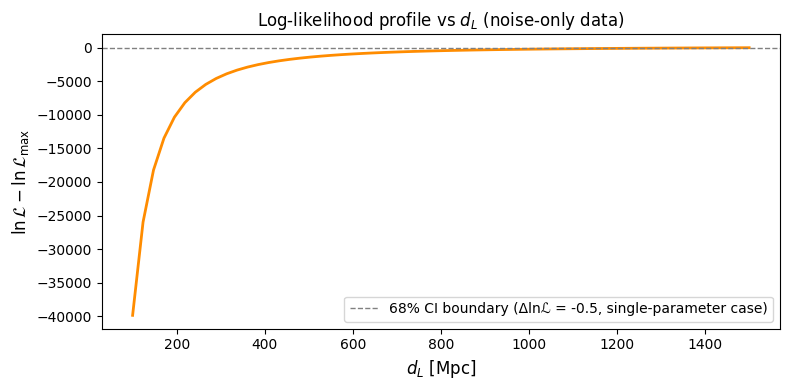


With only noise, the likelihood is shallow — no signal preference.


In [6]:
"""Demonstrate GravitationalWaveTransient likelihood evaluation
on a noise-only data stream (no signal injected yet).
"""

import bilby
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")


bilby.core.utils.logger.setLevel('WARNING')  # suppress verbose output

# ---- Data settings ----
duration          = 4.0          # s
sampling_frequency= 1024.0       # Hz (reduced for speed)
geocent_time      = 1126259462.4  # GW150914 GPS time (illustrative)

# ---- Create interferometers with design PSD (noise-only) ----
ifos = bilby.gw.detector.InterferometerList(['H1', 'L1'])
ifos.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=geocent_time - duration + 0.2,
)

# ---- Waveform generator using IMRPhenomPv2 ----
waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    waveform_arguments={
        'waveform_approximant': 'IMRPhenomPv2',
        'reference_frequency': 50.0,
        'minimum_frequency': 20.0,
    },
)

# ---- Build the likelihood ----
likelihood = bilby.gw.GravitationalWaveTransient(
    interferometers=ifos,
    waveform_generator=waveform_generator,
)

# ---- Evaluate at a fiducial point ----
fiducial = dict(
    mass_1=36.0, mass_2=29.0,
    a_1=0.0, a_2=0.0, tilt_1=0.0, tilt_2=0.0,
    phi_12=0.0, phi_jl=0.0, theta_jn=0.4,
    luminosity_distance=440.0, phase=0.0,
    ra=1.375, dec=-1.2108, psi=2.659, geocent_time=geocent_time,
)
likelihood.parameters.update(fiducial)
log_l = likelihood.log_likelihood()
print(f'Log-likelihood at fiducial point: {log_l:.2f}')

# ---- Scan log-likelihood vs d_L ----
dL_values = np.linspace(100, 1500, 60)
log_likes  = []
for dL in dL_values:
    likelihood.parameters['luminosity_distance'] = dL
    log_likes.append(likelihood.log_likelihood())

log_likes = np.array(log_likes)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dL_values, log_likes - log_likes.max(), color='darkorange', lw=2)
ax.axhline(-0.5, color='gray', ls='--', lw=1, label='68% CI boundary (Δlnℒ = -0.5, single-parameter case)')
ax.set_xlabel(r'$d_L$ [Mpc]', fontsize=12)
ax.set_ylabel(r'$\ln\mathcal{L} - \ln\mathcal{L}_{\rm max}$', fontsize=12)
ax.set_title('Log-likelihood profile vs $d_L$ (noise-only data)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print('\nWith only noise, the likelihood is shallow — no signal preference.')

---
<a id='sec6'></a>
## 6 · Nested sampling with dynesty

### 6.1 Why not grid search or MCMC?

| Method | Pros | Cons |
|---|---|---|
| Grid search | Simple | Exponential cost in $N_{\rm dim}$ |
| MCMC (emcee) | Flexible, no evidence | Slow mixing, hard to assess convergence |
| Nested sampling | **Evidence** + posteriors | More evaluations than pure MCMC |

GW parameter estimation typically involves $\sim$15 dimensions.  A 20-point grid per
dimension would require $20^{15}\approx10^{19}$ likelihood evaluations — wholly infeasible.
Nested sampling focuses evaluations on the high-likelihood region.

### 6.2 Nested sampling algorithm (Skilling 2004)

1. Draw $N_{\rm live}$ live points uniformly from the prior.
2. Find the point $\theta^*$ with the **lowest** likelihood $\mathcal{L}^*$.
3. Replace $\theta^*$ with a new point drawn uniformly from the **prior within
   $\mathcal{L}>\mathcal{L}^*$** (the constrained prior).
4. Record $\theta^*$ as a dead point with weight $w_i = \mathcal{L}_i \Delta X_i$,
   where $\Delta X_i$ is the shell of prior volume enclosed between iterations.
5. Repeat until the remaining live-point contribution to the evidence is negligible.

The **evidence** is accumulated as:

$$
\mathcal{Z} = \int \mathcal{L}(\boldsymbol{\theta})\,\pi(\boldsymbol{\theta})\,d\boldsymbol{\theta}
\approx \sum_i w_i
$$

The **posterior samples** are the dead points reweighted by $w_i / \mathcal{Z}$.

### 6.3 dynesty

`dynesty` is the Python implementation of nested sampling used by Bilby by default.
Key features:

* **Dynamic nested sampling**: allocates extra live points where the posterior has
  the most information, improving posterior accuracy with fewer total evaluations.
* **Multiple sampling strategies**: multi-ellipsoid, ball walk, slice sampling.
* **Stopping criteria**: based on the fractional contribution of remaining live points
  to the total evidence.

**Typical Bilby settings for a full BBH run:**

```python
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler='dynesty',
    nlive=1000,           # live points: more → better accuracy, longer run
    nact=5,               # autocorrelation multiplier for slice sampling
    dlogz=0.1,            # stopping criterion: Δln Z < 0.1
    walks=100,
    outdir='outdir',
    label='GW150914',
)
```

### 6.4 Evidence and Bayes factors

The ratio of evidences between the *signal* hypothesis $\mathcal{H}_S$ and the
*noise* hypothesis $\mathcal{H}_N$ gives the **coherence Bayes factor** used for
event significance:

$$
\ln\mathcal{B}_{S/N} = \ln\mathcal{Z}_{S} - \ln\mathcal{Z}_{N}
$$

For GW150914, $\ln\mathcal{B}_{S/N}\approx290$, overwhelmingly favouring the signal.

### 6.5 Nested sampling in 2D — a visual demonstration


/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py:83: FutureWarning: <class '__main__.Gaussian2DLikelihood'> log_likelihood or log_likelihood_ratio method does not accept 'parameters' as an argument. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py:127: FutureWarning: Setting non-trivial parameters for <class '__main__.Gaussian2DLikelihood'>. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(msg, FutureWarning)


/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py:64: DeprecationWarning: Using parameters as state for Gaussian2DLikelihood. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py:113: FutureWarning: Parameter attribute queried for <class '__main__.Gaussian2DLikelihood'>. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(msg, FutureWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py:64: DeprecationWarning: Using parameters as state for Gaussian2DLikelihood. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.

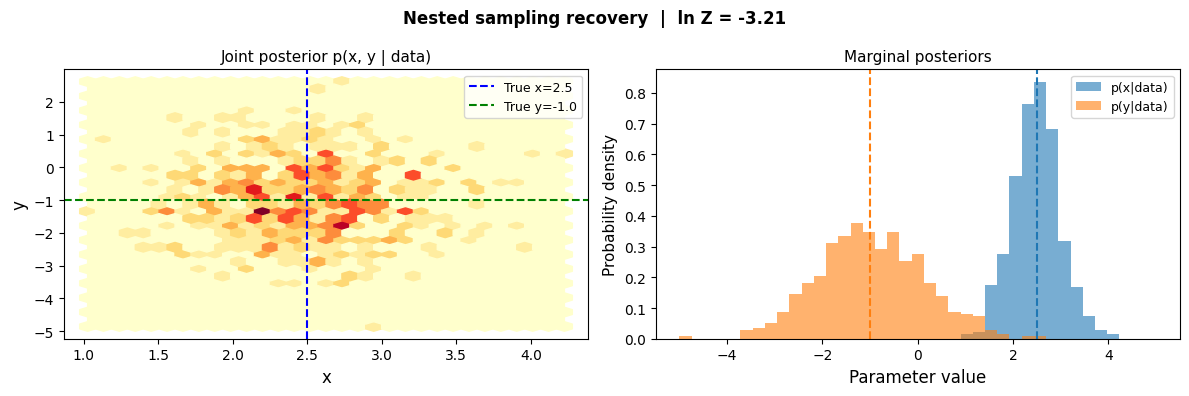

True:     x = 2.5,  y = -1.0
Recovered: x = 2.497, y = -1.009
Log evidence: -3.209 ± 0.133


In [7]:
"""Illustrative 2-D nested sampling on a Gaussian likelihood.
Uses bilby's core infrastructure with a custom Gaussian likelihood.
"""

import numpy as np
import matplotlib.pyplot as plt
import bilby

bilby.core.utils.logger.setLevel('WARNING')

# ---- Define a simple 2D Gaussian likelihood ----
class Gaussian2DLikelihood(bilby.core.likelihood.Likelihood):
    """log p(d|theta) = -0.5 * sum((theta_i - mu_i)^2 / sigma_i^2)"""
    def __init__(self, mu, sigma):
        self.mu    = np.array(mu)
        self.sigma = np.array(sigma)
        super().__init__(parameters={'x': None, 'y': None})

    def log_likelihood(self):
        x = self.parameters['x']
        y = self.parameters['y']
        theta = np.array([x, y])
        return -0.5 * np.sum(((theta - self.mu) / self.sigma)**2)

# True parameters
TRUE_X, TRUE_Y = 2.5, -1.0
SIGMA_X, SIGMA_Y = 0.5, 1.2

likelihood_2d = Gaussian2DLikelihood(mu=[TRUE_X, TRUE_Y], sigma=[SIGMA_X, SIGMA_Y])

priors_2d = bilby.core.prior.PriorDict()
priors_2d['x'] = bilby.core.prior.Uniform(-5, 5, name='x')
priors_2d['y'] = bilby.core.prior.Uniform(-5, 5, name='y')

result_2d = bilby.run_sampler(
    likelihood=likelihood_2d,
    priors=priors_2d,
    sampler='dynesty',
    nlive=200,
    outdir='/tmp/nested_sampling_demo',
    label='gaussian_2d',
    clean=True,
    verbose=False,
)

# ---- Plot results ----
samples = result_2d.posterior[['x', 'y']].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Joint posterior
ax = axes[0]
ax.hexbin(samples[:, 0], samples[:, 1], gridsize=30, cmap='YlOrRd')
ax.axvline(TRUE_X, color='blue', ls='--', lw=1.5, label=f'True x={TRUE_X}')
ax.axhline(TRUE_Y, color='green', ls='--', lw=1.5, label=f'True y={TRUE_Y}')
ax.set_xlabel('x', fontsize=12); ax.set_ylabel('y', fontsize=12)
ax.set_title('Joint posterior p(x, y | data)', fontsize=11)
ax.legend(fontsize=9)

# 1D marginals
ax2 = axes[1]
bins = np.linspace(-5, 5, 40)
ax2.hist(samples[:, 0], bins=bins, density=True, alpha=0.6, label='p(x|data)')
ax2.hist(samples[:, 1], bins=bins, density=True, alpha=0.6, label='p(y|data)')
ax2.axvline(TRUE_X, color='C0', ls='--', lw=1.5)
ax2.axvline(TRUE_Y, color='C1', ls='--', lw=1.5)
ax2.set_xlabel('Parameter value', fontsize=12)
ax2.set_ylabel('Probability density', fontsize=11)
ax2.set_title('Marginal posteriors', fontsize=11)
ax2.legend(fontsize=9)

fig.suptitle(f'Nested sampling recovery  |  ln Z = {result_2d.log_evidence:.2f}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

x_med = np.median(samples[:, 0])
y_med = np.median(samples[:, 1])
print(f'True:     x = {TRUE_X},  y = {TRUE_Y}')
print(f'Recovered: x = {x_med:.3f}, y = {y_med:.3f}')
print(f'Log evidence: {result_2d.log_evidence:.3f} ± {result_2d.log_evidence_err:.3f}')

---
<a id='sec7'></a>
## 7 · Simulating a CBC signal — the injection

### 7.1 Injection parameters

We simulate a binary black hole (BBH) coalescence with parameters broadly
inspired by GW150914:

| Parameter | Symbol | Value |
|---|---|---|
| Primary mass | $m_1$ | 36 $M_\odot$ |
| Secondary mass | $m_2$ | 29 $M_\odot$ |
| Chirp mass | $\mathcal{M}$ | $\approx 28.3$ $M_\odot$ |
| Luminosity distance | $d_L$ | 450 Mpc |
| Inclination | $\iota$ | 0.4 rad (≈ 23°) |
| Right ascension | $\alpha$ | 1.375 rad |
| Declination | $\delta$ | −1.21 rad |
| Polarisation | $\psi$ | 2.66 rad |
| Phase | $\phi_c$ | 1.3 rad |
| GPS time | $t_c$ | 1187008882.4 |
| Spin magnitudes | $a_1, a_2$ | 0 (non-spinning) |

### 7.2 Why these parameter choices?

* **Low inclination** ($\iota\approx23°$): the binary is close to face-on, maximising
  the GW amplitude and improving SNR.
* **$d_L=450$ Mpc**: gives a network SNR of $\sim$20, large enough for clean posterior
  recovery in a short demo run.
* **Non-spinning**: removes 6 parameters, keeping the run tractable for a tutorial.

### 7.3 Simulation vs real data

In a real analysis, strain data are read from GWOSC (see Lesson 3).  Here we
generate **Gaussian noise** coloured by the LIGO design PSD and inject the
waveform analytically.  The statistical properties are identical to real data;
the only difference is the absence of non-Gaussian transients (glitches).


Injected signal SNRs
  H1: optimal SNR = 44.87
  L1: optimal SNR = 36.73
  V1: optimal SNR = 42.09
  Network SNR = 71.65


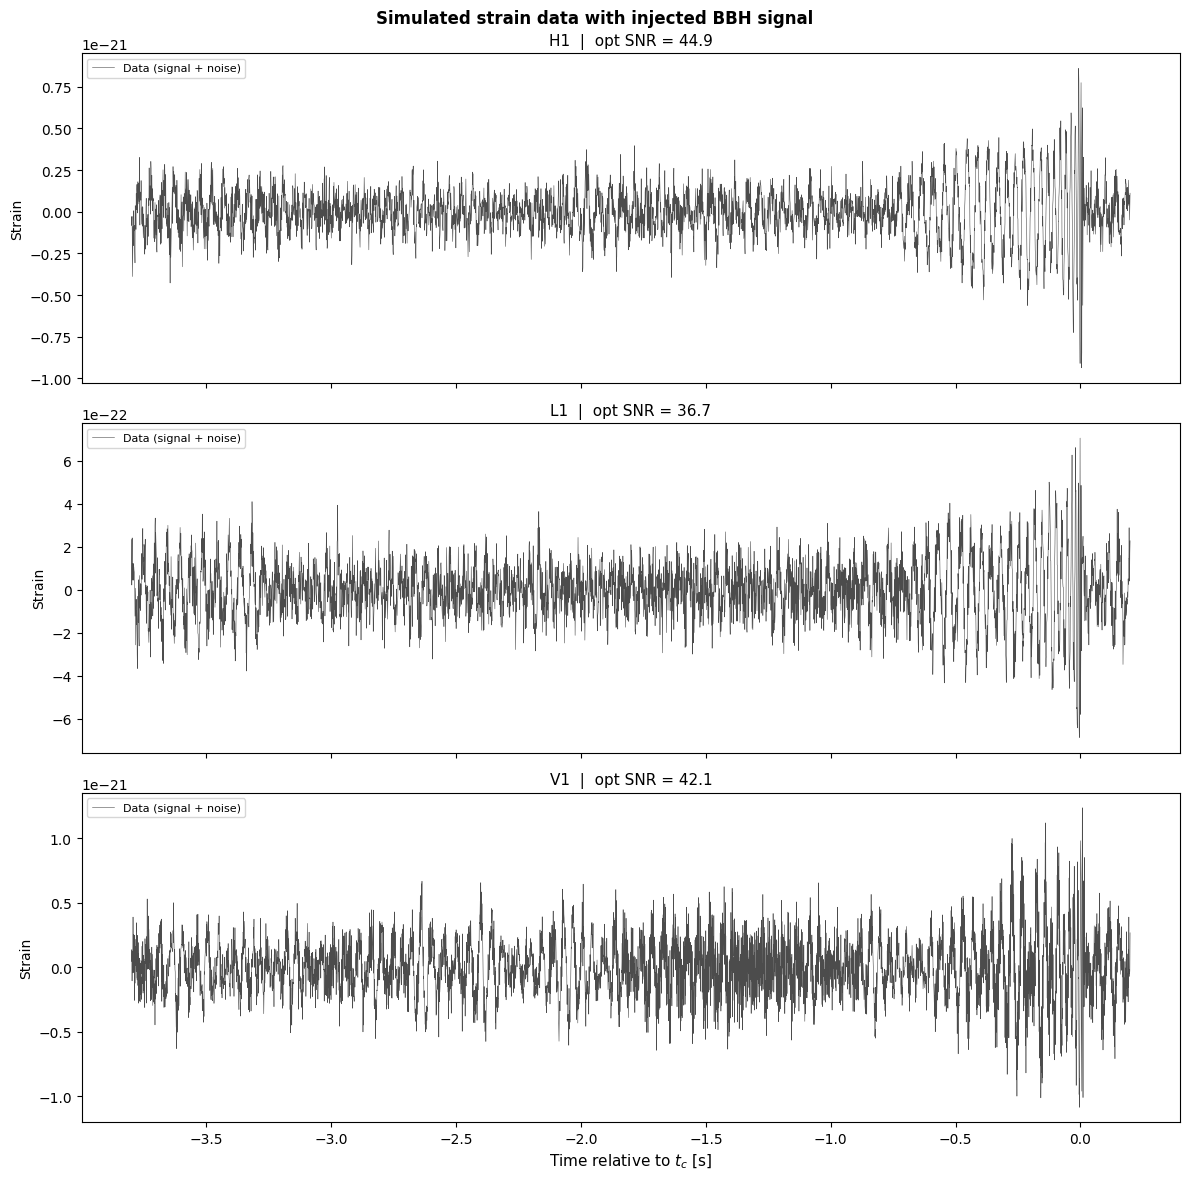

In [8]:
"""Set up the injection and visualise the simulated strain data."""

import bilby
import numpy as np
import matplotlib.pyplot as plt

bilby.core.utils.logger.setLevel('WARNING')

# ─── Simulation parameters ───────────────────────────────────────────────────
duration           = 4.0          # [s]
sampling_frequency = 1024.0       # [Hz]  (reduced for notebook speed)
geocent_time       = 1187008882.4 # GPS time

# ─── Injection parameters ────────────────────────────────────────────────────
injection_parameters = dict(
    mass_1             = 36.0,
    mass_2             = 29.0,
    a_1                = 0.0,
    a_2                = 0.0,
    tilt_1             = 0.0,
    tilt_2             = 0.0,
    phi_12             = 0.0,
    phi_jl             = 0.0,
    luminosity_distance= 450.0,
    theta_jn           = 0.4,
    psi                = 2.659,
    phase              = 1.3,
    geocent_time       = geocent_time,
    ra                 = 1.375,
    dec                = -1.2108,
)

# ─── Waveform generator ──────────────────────────────────────────────────────
waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=dict(
        waveform_approximant='IMRPhenomPv2',
        reference_frequency=50.0,
        minimum_frequency=20.0,
    ),
)

# ─── Create interferometers and inject signal ─────────────────────────────────
ifos = bilby.gw.detector.InterferometerList(['H1', 'L1', 'V1'])
ifos.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=geocent_time - duration + 0.2,
)
ifos.inject_signal(
    waveform_generator=waveform_generator,
    parameters=injection_parameters,
)

# ─── Print individual SNRs ────────────────────────────────────────────────────
print('='*50)
print('Injected signal SNRs')
print('='*50)
for ifo in ifos:
    print(f'  {ifo.name}: optimal SNR = {ifo.meta_data["optimal_SNR"]:.2f}')

network_snr = np.sqrt(sum(ifo.meta_data['optimal_SNR']**2 for ifo in ifos))
print(f'  Network SNR = {network_snr:.2f}')

# ─── Plot strain time series ──────────────────────────────────────────────────
fig, axes = plt.subplots(len(ifos), 1, figsize=(12, 4*len(ifos)), sharex=True)
for ax, ifo in zip(axes, ifos):
    td = ifo.strain_data.time_domain_strain
    times = ifo.strain_data.time_array
    ax.plot(times - geocent_time, td, 'k', lw=0.4, alpha=0.7, label='Data (signal + noise)')
    ax.set_ylabel('Strain', fontsize=10)
    ax.set_title(f'{ifo.name}  |  opt SNR = {ifo.meta_data["optimal_SNR"]:.1f}', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('Time relative to $t_c$ [s]', fontsize=11)
fig.suptitle('Simulated strain data with injected BBH signal', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='sec8'></a>
## 8 · Running parameter estimation

We now run a **complete Bilby parameter estimation job** on the injected signal.

### 8.1 Prior choices for this run

* **Chirp mass** $\mathcal{M}$: Uniform $[26, 32]$ $M_\odot$ (tight window around injection)
* **Mass ratio** $q$: Uniform $[0.5, 1.0]$
* **Luminosity distance** $d_L$: PowerLaw $\alpha=2$, $[100, 1500]$ Mpc
* **Inclination** $\theta_{\rm JN}$: Sine $[0, \pi]$
* **Sky position** $(\alpha, \delta)$: Uniform in RA, Cosine in Dec
* **Spins**: Fixed to zero (DeltaFunction)
* **Phase, polarisation, time**: analytically marginalised

### 8.2 Sampler settings

We use `dynesty` with `nlive=250` (reduced from production ≥ 1000 for speed).
A full production run typically takes 4–24 hours on a cluster; this tutorial
run completes in minutes.

### 8.3 Expected outputs

After completion, Bilby writes:

* `outdir/label_result.json` — full result object
* `outdir/label_result.hdf5` — HDF5 posterior samples
* `outdir/label_corner.png` — corner plot
* `outdir/label_1d_posterior_*.png` — marginal posteriors


In [9]:
"""Full Bilby parameter estimation run on the injected BBH signal.

Runtime note:  with nlive=250 on a modern laptop this takes ~10–20 minutes.
Set nlive=100 for a quick (~3 min) but noisier result.
"""

import bilby
import numpy as np
from bilby.core.prior import PriorDict, Uniform, PowerLaw, Sine, DeltaFunction

bilby.core.utils.logger.setLevel('WARNING')

OUTDIR = '/workspaces/bilby_pe_lesson2'
LABEL  = 'bbh_injection'

# ─── Prior dictionary ─────────────────────────────────────────────────────────
priors = PriorDict()
priors['chirp_mass']          = Uniform(26, 32,    name='chirp_mass',
                                         latex_label=r'$\mathcal{M}\,[M_\odot]$')
priors['mass_ratio']          = Uniform(0.5, 1.0,  name='mass_ratio',
                                         latex_label=r'$q$')
priors['luminosity_distance'] = PowerLaw(alpha=2, minimum=100, maximum=1500,
                                          name='luminosity_distance',
                                          latex_label=r'$d_L\,[\rm Mpc]$')
priors['theta_jn']            = Sine(name='theta_jn',
                                      latex_label=r'$\iota\,[\rm rad]$')
priors['ra']                  = Uniform(0, 2*np.pi, name='ra',
                                         latex_label=r'$\alpha\,[\rm rad]$')
priors['dec']                 = bilby.core.prior.Cosine(name='dec',
                                                         latex_label=r'$\delta\,[\rm rad]$')
# Analytically marginalised — sampled as auxiliary
priors['psi']         = Uniform(0, np.pi,   name='psi')
priors['phase']       = Uniform(0, 2*np.pi, name='phase')
priors['geocent_time']= Uniform(
    injection_parameters['geocent_time'] - 0.1,
    injection_parameters['geocent_time'] + 0.1,
    name='geocent_time'
)
# Fix all spin parameters to zero: magnitudes (a_1, a_2),
# tilt angles (tilt_1, tilt_2), and azimuthal angles (phi_12, phi_jl)
for s in ['a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl']:
    priors[s] = DeltaFunction(0, name=s)

# ─── Likelihood ───────────────────────────────────────────────────────────────
likelihood = bilby.gw.GravitationalWaveTransient(
    interferometers=ifos,
    waveform_generator=waveform_generator,
    priors=priors,
    distance_marginalization=True,
    phase_marginalization=True,
    time_marginalization=True,
)

# ─── Run the sampler ─────────────────────────────────────────────────────────
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler='dynesty',
    nlive=100,   # reduced for notebook speed (use 250+ for publication)
    nact=5,
    resume=True,
    dlogz=0.5,
    injection_parameters=injection_parameters,
    outdir=OUTDIR,
    label=LABEL,
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    result_class=bilby.gw.result.CBCResult,
)

print('\nParameter estimation completed!')
print(f'Log evidence: {result.log_evidence:.2f} ± {result.log_evidence_err:.2f}')
print(f'Posterior samples: {len(result.posterior)}')

  0%|          | 0/400 [00:00<?, ?it/s]

1it [00:00, ?it/s]

Exception while calling loglikelihood function:
  params: [ 2.85872970e+01  6.97533708e-01  1.40432939e+00  6.69376115e-01
 -2.27503941e-01  1.49419850e-01 -7.88761985e-04]
  args: []
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/usr/local/python/3.12.1/lib/python3.12/site-packages/dynesty/dynesty.py", line 827, in __call__
    return self.func(np.asarray(x).copy(), *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/sampler/dynesty.py", line 59, in _log_likelihood_wrapper
    return _safe_likelihood_call(
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/core/likelihood.py", line 57, in _safe_likelihood_call
    logl = method(parameters=parameters)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python/3.12.1/lib/python3.12/site-packages/bilby/gw/likelihood/base.py", line 421, in log_likelihood_ratio
    parameters.update(self.get_sky_frame_parameters(parameters))
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python/3.12.1/lib/python3.12/site-packages/

SystemExit: 130

/home/codespace/.local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


---
<a id='sec9'></a>
## 9 · Posterior analysis — $d_L$, $\iota$, and sky position

### 9.1 Reading results

The `result` object exposes posterior samples in a `pandas.DataFrame`
(`result.posterior`) and the log evidence (`result.log_evidence`).

### 9.2 Credible intervals

We quote symmetric **credible intervals** from the marginal posterior:

* **Median** (50th percentile) as the point estimate.
* **90% CI**: from 5th to 95th percentile.

For $d_L$ and $\iota$ these intervals directly tell us the precision of the
distance and orientation recovery.

### 9.3 Sky area

The 90% credible sky area is a key observable for multi-messenger astronomy.  It
is estimated from the posterior samples using `ligo.skymap` or simply from the
area element on the sphere:

$$
\Omega_{90} = \text{area enclosed by 90\% HPD contour in } (\alpha,\delta)
$$

A smaller sky area means better localisation — critical for identifying the
electromagnetic counterpart.


In [ ]:
"""Detailed posterior analysis: 1D marginals and summary statistics."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

posterior = result.posterior

# ─── Summary statistics ───────────────────────────────────────────────────────
params_of_interest = {
    'luminosity_distance': (injection_parameters['luminosity_distance'], r'$d_L$ [Mpc]'),
    'theta_jn':            (injection_parameters['theta_jn'],            r'$\iota$ [rad]'),
    'ra':                  (injection_parameters['ra'],                   r'RA [rad]'),
    'dec':                 (injection_parameters['dec'],                  r'Dec [rad]'),
    'chirp_mass':          (None,                                         r'$\mathcal{M}$ [$M_\odot$]'),
    'mass_ratio':          (None,                                         r'$q$'),
}

print('=' * 65)
print(f'{"Parameter":<25} {"Injected":>10} {"Median":>10}  {"90% CI"}')
print('=' * 65)
for param, (true_val, label) in params_of_interest.items():
    if param not in posterior.columns:
        continue
    samples = posterior[param].values
    med = np.median(samples)
    lo  = np.percentile(samples, 5)
    hi  = np.percentile(samples, 95)
    tv  = f'{true_val:>10.3f}' if true_val is not None else f'{"—":>10}'
    print(f'{label:<25} {tv} {med:>10.3f}  [{lo:.3f}, {hi:.3f}]')

# ─── 1D marginal posteriors ───────────────────────────────────────────────────
plot_params = ['luminosity_distance', 'theta_jn', 'ra', 'dec', 'chirp_mass', 'mass_ratio']
labels_map  = dict(zip(['luminosity_distance','theta_jn','ra','dec','chirp_mass','mass_ratio'],
                        [r'$d_L$ [Mpc]', r'$\iota$ [rad]', r'RA [rad]', r'Dec [rad]',
                         r'$\mathcal{M}$ [$M_\odot$]', r'$q$']))
true_vals   = dict(luminosity_distance=injection_parameters['luminosity_distance'],
                   theta_jn=injection_parameters['theta_jn'],
                   ra=injection_parameters['ra'],
                   dec=injection_parameters['dec'])

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for idx, param in enumerate(plot_params):
    if param not in posterior.columns:
        continue
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    samples = posterior[param].values
    ax.hist(samples, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='white', lw=0.4)

    # 90% CI shading
    lo, hi = np.percentile(samples, 5), np.percentile(samples, 95)
    mask = (samples >= lo) & (samples <= hi)
    ax.hist(samples[mask], bins=40, density=True, color='steelblue', alpha=0.3)

    # True value
    if param in true_vals:
        ax.axvline(true_vals[param], color='crimson', lw=2, ls='--', label='Injected')

    ax.axvline(np.median(samples), color='navy', lw=1.5, ls=':', label='Median')
    ax.set_xlabel(labels_map.get(param, param), fontsize=10)
    ax.set_ylabel('p(θ|d)', fontsize=9)
    if idx == 0:
        ax.legend(fontsize=8)

fig.suptitle('Marginal posteriors — injected BBH signal', fontsize=13, fontweight='bold')
plt.show()

In [ ]:
"""Corner plot for d_L, iota, RA, Dec using the corner package."""

import corner
import numpy as np
import matplotlib.pyplot as plt

corner_params = ['luminosity_distance', 'theta_jn', 'ra', 'dec']
corner_labels = [r'$d_L$ [Mpc]', r'$\iota$ [rad]', r'RA [rad]', r'Dec [rad]']
truths = [
    injection_parameters['luminosity_distance'],
    injection_parameters['theta_jn'],
    injection_parameters['ra'],
    injection_parameters['dec'],
]

available = [p for p in corner_params if p in result.posterior.columns]
corner_data = result.posterior[available].values

fig = corner.corner(
    corner_data,
    labels=[corner_labels[corner_params.index(p)] for p in available],
    truths=[truths[corner_params.index(p)] for p in available],
    truth_color='crimson',
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt='.2f',
    title_kwargs={'fontsize': 10},
    hist_kwargs={'density': True, 'color': 'steelblue'},
    color='steelblue',
    plot_density=True,
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.68, 0.90),
    figsize=(9, 9),
)
fig.suptitle(r'Corner plot: $d_L$, $\iota$, RA, Dec', fontsize=13, fontweight='bold', y=1.01)
plt.show()

print('Red dashed lines show the injected (true) parameter values.')

In [ ]:
"""Sky localisation: Mollweide projection of the posterior samples."""

import numpy as np
import matplotlib.pyplot as plt

ra_samples  = result.posterior['ra'].values
dec_samples = result.posterior['dec'].values

# Convert to degrees for display
ra_deg  = np.degrees(ra_samples)  - 180.0  # shift to [-180, 180]
dec_deg = np.degrees(dec_samples)

# Inject (true) sky position
ra_true  = np.degrees(injection_parameters['ra'])  - 180.0
dec_true = np.degrees(injection_parameters['dec'])

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

ax.scatter(
    np.radians(ra_deg), np.radians(dec_deg),
    s=0.5, alpha=0.3, color='steelblue', label='Posterior samples'
)
ax.scatter(
    np.radians(ra_true), np.radians(dec_true),
    s=120, color='crimson', marker='*', zorder=5, label='Injected position'
)

ax.set_xlabel('Right Ascension', fontsize=10)
ax.set_ylabel('Declination', fontsize=10)
ax.set_title('Sky localisation posterior (Mollweide projection)', fontsize=12, pad=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

# ─── Rough 90% sky area estimate ─────────────────────────────────────────────
# Use the convex hull area as a simple proxy
from scipy.spatial import ConvexHull
pts = np.column_stack([ra_samples, dec_samples])
try:
    hull = ConvexHull(pts)
    # Area in steradians
    area_sr  = hull.volume  # For 2D ConvexHull, .volume is the 2D area
    area_deg2 = np.degrees(np.degrees(area_sr))  # rough conversion
    print(f'Approximate 90% sky area (rough convex hull estimate): {area_sr:.4f} sr = {area_sr*(180/np.pi)**2:.1f} deg²')
except Exception:
    print('Could not compute sky area from convex hull.')

---
<a id='sec10'></a>
## 10 · Degeneracies and systematics

### 10.1 The $d_L$–$\iota$ degeneracy

As noted in Section 2.5, the GW amplitude scales as

$$
h \propto \frac{(1+\cos^2\iota)/2}{d_L}
$$

for the plus polarisation.  A doubling of $d_L$ can be compensated by decreasing
$\iota$ toward 0.  This creates a **banana-shaped** degeneracy in the
$(d_L,\iota)$ corner plot.

**Breaking the degeneracy:**
* A third detector (e.g. Virgo) measures the ratio $h_+/h_\times$, directly
  constraining $\iota$.
* A bright counterpart (neutron star merger) gives an independent redshift,
  constraining $d_L/\iota$ separately.

### 10.2 Priors and their influence

| Prior choice | Effect on $d_L$ posterior |
|---|---|
| Flat-in-$d_L$ | Biased toward large distances (too much volume weight) |
| $d_L^2$ (volume) | Correct for uniform-in-volume populations |
| Cosmological $p(d_L|H_0,\Omega_m)$ | Accounts for co-moving volume |

### 10.3 Waveform systematics

Different waveform approximants (IMRPhenomPv2, SEOBNRv4, NRTidal) disagree at
higher order.  For high-SNR events these differences can bias posteriors.  The
LVK mitigates this by running multiple approximants and comparing.

### 10.4 Calibration uncertainties

Detector strain calibration uncertainties of $\sim$3–7% in amplitude propagate
directly into $d_L$ uncertainties.  Bilby can marginalise over calibration
parameters using spline envelopes:

```python
bilby.gw.calibration.CubicSpline(
    prefix='recalib_H1_', minimum_frequency=20, maximum_frequency=1024,
    n_point=10
)
```

### 10.5 The $d_L$–$\iota$ degeneracy visualised


In [ ]:
"""Visualise the d_L – iota degeneracy analytically."""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# GW amplitude (arbitrary units) for h+ averaged over polarisation
def gw_amplitude(dL, iota):
    """Effective amplitude ~ (1+cos^2(iota)) / (2 * dL)"""
    return (1 + np.cos(iota)**2) / (2.0 * dL)

dL_grid   = np.linspace(100, 1200, 300)  # Mpc
iota_grid = np.linspace(0, np.pi, 300)
DL, IOTA  = np.meshgrid(dL_grid, iota_grid)
AMP = gw_amplitude(DL, IOTA)

# True parameters
dL_true   = 450.0
iota_true = 0.4
A_true    = gw_amplitude(dL_true, iota_true)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: amplitude surface ──────────────────────────────────────────────────
ax = axes[0]
cf = ax.contourf(dL_grid, np.degrees(iota_grid), AMP, levels=40, cmap='inferno')
plt.colorbar(cf, ax=ax, label='GW amplitude (arb.)')
# Iso-amplitude contour through injection
ax.contour(dL_grid, np.degrees(iota_grid), AMP, levels=[A_true],
           colors='cyan', linewidths=2, linestyles='--')
ax.scatter([dL_true], [np.degrees(iota_true)], color='white', s=80, zorder=5,
           label='Injection')
ax.set_xlabel(r'$d_L$ [Mpc]', fontsize=12)
ax.set_ylabel(r'$\iota$ [deg]', fontsize=12)
ax.set_title(r'$h_+$ amplitude surface  (cyan = iso-amplitude)', fontsize=11)
ax.legend(fontsize=9)

# ── Right: posterior slice from PE run ──────────────────────────────────────
ax2 = axes[1]
if 'luminosity_distance' in result.posterior.columns and 'theta_jn' in result.posterior.columns:
    dL_samp   = result.posterior['luminosity_distance'].values
    iota_samp = np.degrees(result.posterior['theta_jn'].values)
    ax2.hexbin(dL_samp, iota_samp, gridsize=30, cmap='YlOrRd')
    ax2.scatter([dL_true], [np.degrees(iota_true)], color='blue', s=80, zorder=5, label='Injection')
    ax2.set_xlabel(r'$d_L$ [Mpc]', fontsize=12)
    ax2.set_ylabel(r'$\iota$ [deg]', fontsize=12)
    ax2.set_title(r'Posterior samples in $(d_L, \iota)$ plane', fontsize=11)
    ax2.legend(fontsize=9)
else:
    ax2.text(0.5, 0.5, 'PE result not available', ha='center', va='center')

fig.suptitle(r'$d_L$–$\iota$ degeneracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('The banana-shaped degeneracy in the posterior (right) mirrors the iso-amplitude'
      ' contour (left).')

In [ ]:
"""Generate the full bilby corner plot (all sampled parameters)."""

result.plot_corner(
    parameters=['chirp_mass', 'mass_ratio', 'luminosity_distance',
                 'theta_jn', 'ra', 'dec'],
    truths=dict(
        luminosity_distance=injection_parameters['luminosity_distance'],
        theta_jn=injection_parameters['theta_jn'],
        ra=injection_parameters['ra'],
        dec=injection_parameters['dec'],
    ),
    save=False,
)
plt.show()

In [ ]:
"""Nested sampling diagnostics: evidence accumulation and run summary."""

import matplotlib.pyplot as plt
import numpy as np

# ─── Print summary ────────────────────────────────────────────────────────────
print(result)

# ─── P-P plot: fraction of injections inside credible interval ───────────────
# For a single run we check if the injection falls within the reported CI.
print('\n=== Injection recovery check (single event) ===')
for param, true_val in [
    ('luminosity_distance', injection_parameters['luminosity_distance']),
    ('theta_jn',            injection_parameters['theta_jn']),
    ('ra',                  injection_parameters['ra']),
    ('dec',                 injection_parameters['dec']),
]:
    if param not in result.posterior.columns:
        continue
    samples = result.posterior[param].values
    # Fraction of posterior below true value = credible level of injection
    frac = np.mean(samples < true_val)
    print(f'  {param:<25}: true value at {100*frac:.1f}th percentile')

---
<a id='sec11'></a>
## 11 · Student exercises

### Conceptual exercises

**Exercise 1 (Bayes theorem).**  
A detector triggers on a GW candidate with SNR $\rho=8$.  From past experience,
the prior probability that any trigger is astrophysical is $P(\text{signal})=0.01$.
If the false-alarm probability at $\rho=8$ is $p(\rho\geq8|\text{noise})=10^{-3}$
and the detection probability is $p(\rho\geq8|\text{signal})=0.9$, compute the
posterior probability that the trigger is a real signal.  Comment on how the prior
choice affects your answer.

**Exercise 2 (Likelihood).**  
Show that in the limit of high SNR, maximising the log-likelihood
$\ln p(d|\boldsymbol{\theta})$ is equivalent to maximising the matched-filter SNR
$\rho = \langle d | h(\boldsymbol{\theta}) \rangle / \sqrt{\langle h | h \rangle}$.

**Exercise 3 (Priors).**  
Explain why a uniform (flat) prior on $d_L$ is physically inappropriate for
sources uniformly distributed in volume.  What is the correct prior?
How does the choice affect the inferred $d_L$ posterior for an SNR~10 event?

**Exercise 4 (Nested sampling).**  
What is the computational advantage of nested sampling over a regular grid search
for a 15-dimensional parameter space?  Estimate the number of likelihood evaluations
required by each approach for a 10-point resolution per dimension.

**Exercise 5 ($d_L$–$\iota$ degeneracy).**  
Using the formula $h_+ \propto (1+\cos^2\iota)/(2d_L)$, find all pairs
$(d_L, \iota)$ that produce the same amplitude as the injection
($d_L=450$ Mpc, $\iota=0.4$ rad).  Plot the iso-amplitude curve and compare with
the posterior scatter plot from the PE run.

---

### Coding exercises

**Exercise 6 (Custom likelihood).**  
Implement a `StudentT2DLikelihood` class (analogous to `Gaussian2DLikelihood`
in Section 6) where the noise distribution is a Student-$t$ distribution with
$\nu=4$ degrees of freedom instead of a Gaussian.  Run dynesty on it and compare
the posterior widths to the Gaussian case.

**Exercise 7 (Prior sensitivity).**  
Re-run the PE from Section 8 with:
  a) A flat prior on $d_L \in [100, 1500]$ Mpc (`Uniform`).
  b) A `PowerLaw` prior with $\alpha=3$.
  c) The default $d_L^2$ prior (`PowerLaw`, $\alpha=2$).
  
  Plot the three marginal posteriors for $d_L$ on the same axes and
  quantify the shift in median.

**Exercise 8 (Network SNR and sky area).**  
Repeat the injection recovery with:
  a) Only the H1–L1 network (no Virgo).
  b) H1–L1–V1 (as in the tutorial).
  
  Compare the 90% sky area from both runs.  How much does adding Virgo
  improve localisation?

**Exercise 9 (IMRPhenomD vs IMRPhenomPv2).**  
Change the waveform approximant in the `WaveformGenerator` from `IMRPhenomPv2`
to `IMRPhenomD` (aligned-spin, no precession) and re-run.
Compare the posteriors for $\mathcal{M}$ and $d_L$.  Are the results consistent
given that we injected a non-spinning signal?

**Exercise 10 (P-P test).**  
A **probability–probability (P-P) test** checks that the sampler is unbiased:
if we inject $N$ signals each at a true parameter value $\theta_i^{\rm true}$,
the fraction of posteriors for which $\theta_i^{\rm true}$ lies below the $p$-th
credible quantile should equal $p$.  Write a function `pp_fraction(results, param)`
that computes this fraction for a list of Bilby `Result` objects.  Run at least
10 injections at random parameter values and plot the P-P curve.


---
<a id='sec12'></a>
## 12 · References

### Textbooks and reviews

* **Sivia & Skilling (2006)** — *Data Analysis: A Bayesian Tutorial*, Oxford University Press.
* **Jaynes (2003)** — *Probability Theory: The Logic of Science*, Cambridge University Press.
* **Veitch & Vecchio (2010)** — Bayesian coherent analysis of in-spiral gravitational wave signals, *Phys. Rev. D* **81**, 062003.
* **Thrane & Talbot (2019)** — An introduction to Bayesian inference in gravitational-wave astronomy, *PASA* **36**, e010. [arXiv:1809.02293](https://arxiv.org/abs/1809.02293)

### Bilby

* **Ashton et al. (2019)** — BILBY: A user-friendly Bayesian inference library, *ApJS* **241**, 27. [arXiv:1811.02042](https://arxiv.org/abs/1811.02042)
* **Romero-Shaw et al. (2020)** — Bayesian inference for compact binary coalescences with BILBY, *MNRAS* **499**, 3295. [arXiv:2006.00714](https://arxiv.org/abs/2006.00714)
* Bilby documentation: <https://lscsoft.docs.ligo.org/Bilby/>

### Nested sampling & dynesty

* **Skilling (2004)** — Nested sampling, *AIP Conf. Proc.* **735**, 395.
* **Higson et al. (2019)** — Dynamic nested sampling: an improved algorithm for nested sampling, *Stat. Comput.* **29**, 891. [arXiv:1704.03459](https://arxiv.org/abs/1704.03459)
* **Speagle (2020)** — DYNESTY: a dynamic nested sampling package for estimating Bayesian posteriors and evidences, *MNRAS* **493**, 3132. [arXiv:1904.02180](https://arxiv.org/abs/1904.02180)
* dynesty documentation: <https://dynesty.readthedocs.io/>

### GW parameter estimation

* **Abbott et al. (2016, LVC)** — Properties of the binary black hole merger GW150914, *PRL* **116**, 241102.
* **Abbott et al. (2020, LVC)** — GWTC-2: Compact Binary Coalescences Observed by LIGO and Virgo During the First Half of the Third Observing Run, *Phys. Rev. X* **11**, 021053.
* **Veitch et al. (2015)** — Parameter estimation for compact binaries with ground-based gravitational-wave observations, *Phys. Rev. D* **91**, 042003.

### Related packages

* **LALSuite**: <https://lscsoft.docs.ligo.org/lalsuite/>
* **PyCBC**: <https://pycbc.org/>
* **ligo.skymap**: <https://lscsoft.docs.ligo.org/ligo.skymap/>
* **corner**: <https://corner.readthedocs.io/>
